/tmp/ipykernel_2103695/1711361351.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


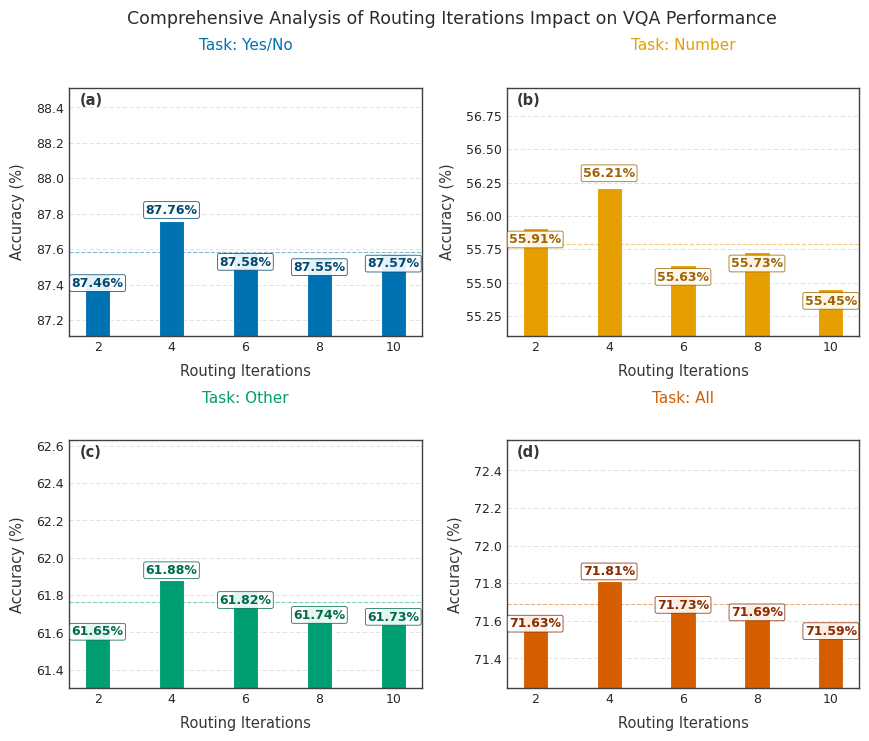

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ==================== 学术级配置 ====================
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({
    'font.size': 9.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 11.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#404040',  # 深灰轴线
    'grid.color': '#d3d3d3',     # 浅灰网格线
    'text.color': '#363636',     # 主体文字黑
    'axes.labelcolor': '#363636',# 轴标签黑
    'savefig.dpi': 1200,
    'savefig.format': 'eps'
})
# ==================== 用户指定配色系统 ====================
TASK_CONFIG = {
    'Yes/No': {'color': '#0072B2', 'marker': 'o', 'annotate_color': '#004a72'},
    'Number': {'color': '#E69F00', 'marker': 's', 'annotate_color': '#a06300'},
    'Other': {'color': '#009E73', 'marker': '^', 'annotate_color': '#006b4e'},
    'All': {'color': '#D55E00', 'marker': 'D', 'annotate_color': '#8a2b00'}
}
# ==================== 多级标注优化系统 ====================
def academic_annotate(ax, bars, task):
    """三阶标注定位引擎：颜色增强+对比优化"""
    y = [bar.get_height() for bar in bars]
    max_val, min_val = max(y), min(y)
    for bar in bars:
        val = bar.get_height()
        # 动态定位策略
        if val == max_val:
            offset = (max_val - min_val)*0.08  # 基于数据范围自适应
            va_pos = 'bottom'
        else:
            offset = -(max_val - min_val)*0.05
            va_pos = 'top'
        ax.text(
            bar.get_x() + bar.get_width()/2., 
            val + offset,
            f'{val:.2f}%',
            ha='center', 
            va=va_pos,
            color=TASK_CONFIG[task]['annotate_color'],  # 使用专用注释色
            fontsize=9,
            fontweight='550',  # 半粗体增强可读性
            bbox=dict(
                boxstyle="round,pad=0.15",
                fc="white",
                ec=TASK_CONFIG[task]['annotate_color'],  # 注释色边框
                lw=0.6,
                alpha=0.9
            )
        )
# ==================== 论文级图表引擎 ====================
def create_journal_plot(data):
    df = data.melt(id_vars='Iterations', var_name='Task', value_name='Accuracy')
    fig, axs = plt.subplots(2, 2, figsize=(10.2, 7.8),  # IEEE双栏兼容尺寸
                          gridspec_kw={'wspace':0.24, 'hspace':0.42})
    for idx, task in enumerate(TASK_CONFIG.keys()):
        ax = axs[idx//2, idx%2]
        subset = df[df['Task'] == task].sort_values('Iterations')
        # 柱状图绘制
        bars = ax.bar(
            'Iterations', 'Accuracy', 
            data=subset,
            width=0.68,
            color=TASK_CONFIG[task]['color'],
            edgecolor='white',
            linewidth=0.8
        )
        # 调用增强标注
        academic_annotate(ax, bars, task)
        # 坐标系统
        ax.set_xlabel('Routing Iterations', labelpad=7)
        ax.set_ylabel('Accuracy (%)', labelpad=8)
        ax.set_xticks(subset['Iterations'])
        ax.set_ylim(subset['Accuracy'].min()-0.35, subset['Accuracy'].max()+0.75)
        # 网格优化
        ax.yaxis.grid(True, linestyle=(0, (5, 3)), linewidth=0.6, alpha=0.8)
        ax.xaxis.grid(False)
        # 子图标题（上中对齐，无加粗）
        ax.text(
            0.5, 1.14,  # X位置居中，Y轴标题上方
            f'Task: {task}',
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            color=TASK_CONFIG[task]['color'],
            fontsize=11
        )
        # 统计基线
        ax.axhline(subset['Accuracy'].mean(), 
                  color=TASK_CONFIG[task]['color'], 
                  linewidth=0.8, 
                  linestyle='--',
                  alpha=0.5)
        # 子图标识符
        ax.text(
            0.03, 0.98, f'({chr(97+idx)})',
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=10.5,
            color='#363636',
            weight='semibold'
        )
    # 全局优化
    plt.suptitle("Comprehensive Analysis of Routing Iterations Impact on VQA Performance", 
                y=0.98, 
                fontsize=12.5,
                color='#2b2b2b')
    return fig
# ==================== 执行与验证 ====================
iteration_data = pd.DataFrame({
    'Iterations': [2,4,6,8,10],
    'Yes/No': [87.46,87.76,87.58,87.55,87.57],
    'Number': [55.91,56.21,55.63,55.73,55.45],
    'Other': [61.65,61.88,61.82,61.74,61.73],
    'All': [71.63,71.81,71.73,71.69,71.59]
})
figure = create_journal_plot(iteration_data)
figure.savefig('Journal_Ready_Visualization.eps', 
              transparent=True, 
              bbox_inches='tight')
plt.show()


/tmp/ipykernel_2103695/3945617953.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_2103695/3945617953.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2103695/3945617953.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  final_fig.savefig('./fusion1/test/test2.eps', format='eps', bbox_inches='tight')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/home/ubuntu/miniconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes t

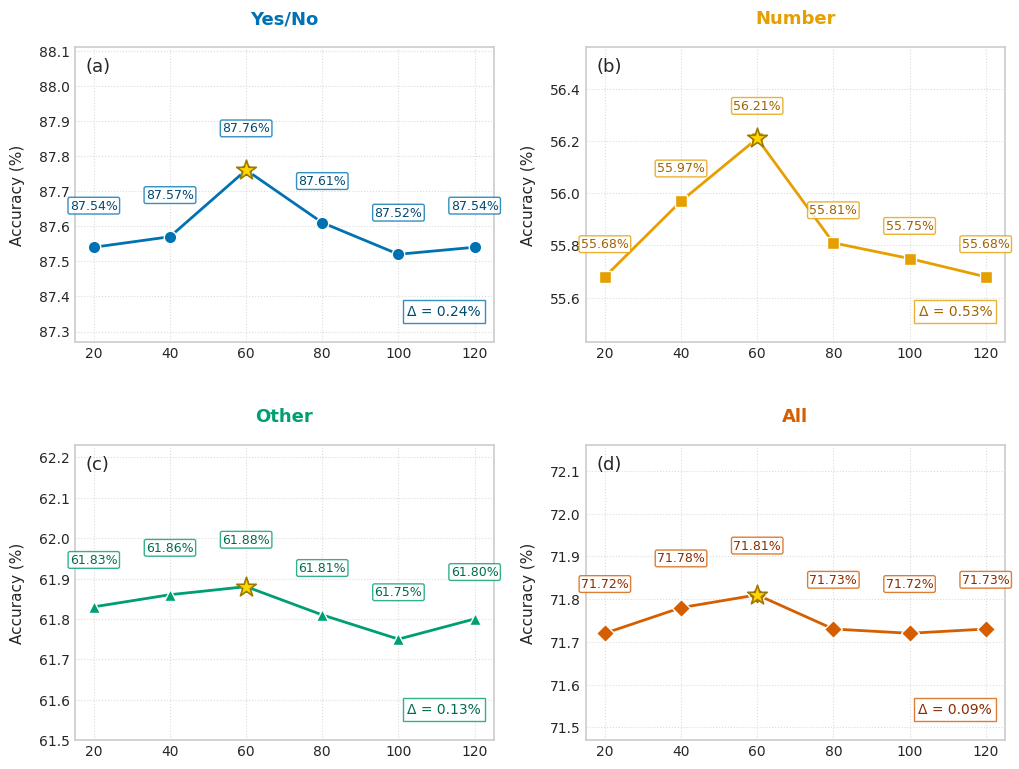

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==================== 学术级配置优化 ====================
plt.style.use('seaborn-whitegrid')
sns.set_palette("colorblind")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans'],
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2.0,
    'lines.markersize': 9,
    'legend.fontsize': 10,
    'savefig.dpi': 1200,
    'savefig.format': 'tiff',
    'savefig.bbox': 'tight'
})

# ==================== 统一配色调整（柔和但区分明显） ====================
TASK_CONFIG = {
    'Yes/No': {'color': '#0072B2', 'marker': 'o', 'annotate_color': '#004a72'},
    'Number': {'color': '#E69F00', 'marker': 's', 'annotate_color': '#a06300'},
    'Other': {'color': '#009E73', 'marker': '^', 'annotate_color': '#006b4e'},
    'All': {'color': '#D55E00', 'marker': 'D', 'annotate_color': '#8a2b00'}
}

# ==================== 数据准备 ====================
capsule_data = pd.DataFrame({
    'Capsules': [20, 40, 60, 80, 100, 120],
    'Yes/No': [87.54, 87.57, 87.76, 87.61, 87.52, 87.54],
    'Number': [55.68, 55.97, 56.21, 55.81, 55.75, 55.68],
    'Other': [61.83, 61.86, 61.88, 61.81, 61.75, 61.80],
    'All': [71.72, 71.78, 71.81, 71.73, 71.72, 71.73]
})

# ==================== 优化算法增强 ====================
def find_optimal(data, metric_cols):
    optimal_dict = {}
    for col in metric_cols:
        idx = data[col].idxmax()
        optimal_dict[col] = {
            'capsules': data.loc[idx, 'Capsules'],
            'value': data.loc[idx, col],
            'delta': data[col].max() - data[col].min()
        }
    return optimal_dict

# ==================== 可视化引擎 ====================
def create_optimal_plot(data):
    fig, axs = plt.subplots(2, 2, figsize=(12, 9),
                            gridspec_kw={'wspace': 0.22, 'hspace': 0.35})
    
    optima = find_optimal(data, ['Yes/No', 'Number', 'Other', 'All'])
    title_color = '#2e3b4e'  # 统一标题颜色
    
    for idx, task in enumerate(optima.keys()):
        config = TASK_CONFIG[task]
        ax = axs[idx//2, idx%2]
        x = data['Capsules']
        y = data[task]
        
        ax.plot(x, y, color=config['color'], marker=config['marker'],
                markersize=9, markeredgecolor='w', linewidth=2, zorder=2)
        
        # 数据标签向下微调
        for xi, yi in zip(x, y):
            ax.text(xi, yi + 0.10, f'{yi:.2f}%', 
                    ha='center', va='bottom', fontsize=9,
                    color=config['annotate_color'],
                    bbox=dict(boxstyle="round,pad=0.15",
                              fc="white", ec=config['color'], alpha=0.8))
        
        # 最优点
        opt = optima[task]
        ax.scatter(opt['capsules'], opt['value'], 
                   s=220, marker='*',
                   color='gold', edgecolor='#9d7900', linewidth=1.2,
                   zorder=5, label='Optimal Point')
        
        # 波动范围 Δ
        ax.text(0.97, 0.08, f'Δ = {opt["delta"]:.2f}%',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=10, color=config['annotate_color'],
                bbox=dict(facecolor='white', alpha=0.8,
                          edgecolor=config['color'], pad=3))
        
        #ax.set_xlabel('Number of Capsules', labelpad=10)
        ax.set_ylabel('Accuracy (%)', labelpad=10)
        
        # 自定义任务标题（用对应颜色 + 加粗，放在子图上方）
        ax.text(0.5, 1.08, task, transform=ax.transAxes,
                ha='center', fontsize=13,
                color=config['color'], fontweight='bold')
        ax.set_xticks(x)
        ax.set_ylim(min(y) - 0.25, max(y) + 0.35)
        ax.grid(True, which='both', linestyle=':', alpha=0.7)
        
        ax.text(0.025, 0.965, f'({chr(97 + idx)})', 
                transform=ax.transAxes,
                fontsize=13, va='top')
    
    plt.tight_layout()
    return fig

# ==================== 执行与输出 ====================
final_fig = create_optimal_plot(capsule_data)
final_fig.savefig('./fusion1/test/test2.eps', format='eps', bbox_inches='tight')

plt.show()


/tmp/ipykernel_2103695/1877466995.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  performance_fig.savefig('Refined_Visualization.eps', bbox_inches='tight')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/home/ubuntu/miniconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


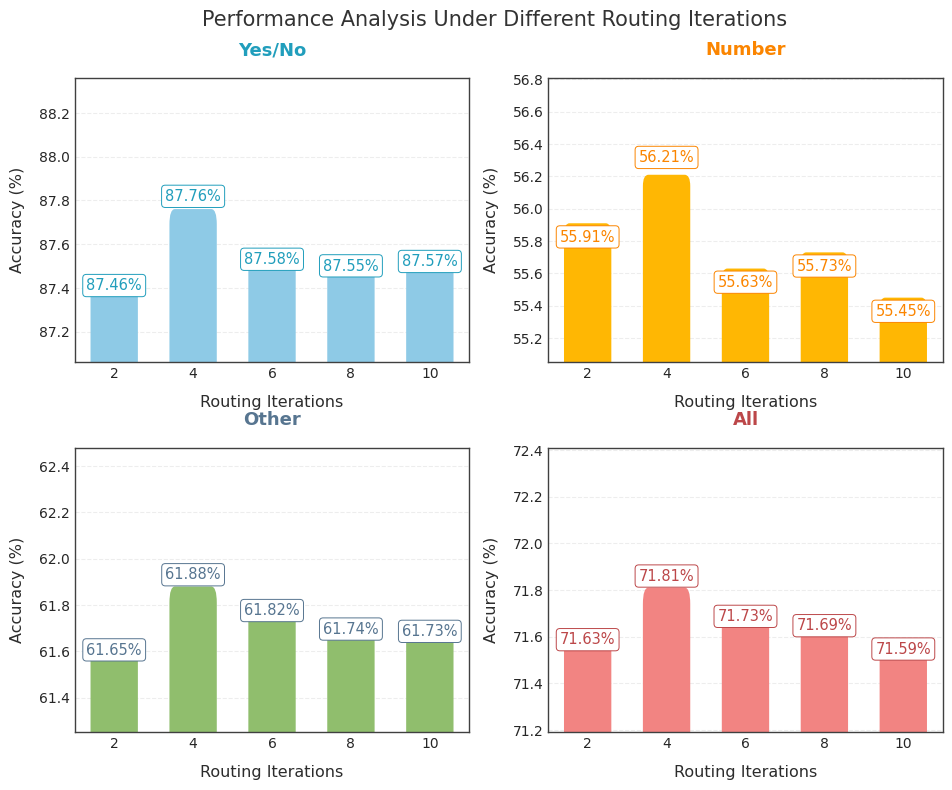

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ==================== 学术级配置优化 ====================
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11.5,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#404040',
    'grid.color': '#dcdcdc',
    'text.color': '#2c2c2c',
    'axes.labelcolor': '#2c2c2c',
    'savefig.dpi': 1200,
    'savefig.format': 'eps',
    'figure.autolayout': True
})

# ==================== 小清新配色系统 ====================
TASK_CONFIG = {
    'Yes/No': {'color': '#8ecae6', 'annotate_color': '#219ebc'},
    'Number': {'color': '#ffb703', 'annotate_color': '#fb8500'},
    'Other': {'color': '#90be6d', 'annotate_color': '#577590'},
    'All': {'color': '#f28482', 'annotate_color': '#bc4749'}
}

# ==================== 圆角条形图辅助函数 ====================
def round_bar(ax, x, height, width, color, radius=0.1):
    for xi, hi in zip(x, height):
        bbox = FancyBboxPatch(
            (xi - width/2, 0), width, hi,
            boxstyle=f"round,pad=0.0,rounding_size={radius}",
            ec='none', fc=color, zorder=2)
        ax.add_patch(bbox)

# ==================== 精准标注系统 ====================
def optimized_annotation(ax, x, height, task):
    """动态标注系统2.0"""
    max_h = max(height)
    min_h = min(height)
    data_range = max_h - min_h if max_h != min_h else 1

    for xi, hi in zip(x, height):
        offset = data_range * 0.05 if hi != max_h else data_range * 0.08
        va = 'bottom' if hi == max_h else 'top'
        ax.text(xi,
                hi + (offset if va == 'bottom' else -offset),
                f'{hi:.2f}%',
                ha='center', va=va,
                fontsize=10.5,
                color=TASK_CONFIG[task]['annotate_color'],
                fontweight='medium',
                bbox=dict(boxstyle="round,pad=0.25",
                          fc='white',
                          ec=TASK_CONFIG[task]['annotate_color'],
                          lw=0.7))

# ==================== 增强可视化引擎 ====================
def generate_advanced_plot(data):
    df = data.melt(id_vars='Iterations', var_name='Task', value_name='Accuracy')
    fig, axs = plt.subplots(2, 2, figsize=(11.2, 8.5), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})

    for idx, task in enumerate(TASK_CONFIG):
        ax = axs[idx // 2, idx % 2]
        task_data = df[df['Task'] == task].sort_values('Iterations')
        x = np.arange(len(task_data))
        accuracy = task_data['Accuracy'].values
        iter_labels = task_data['Iterations'].values

        # 添加圆角条形图
        round_bar(ax, x, accuracy, width=0.6, color=TASK_CONFIG[task]['color'], radius=0.07)

        # 标注优化
        optimized_annotation(ax, x, accuracy, task)

        # 坐标轴与刻度优化
        ax.set_xlim(-0.5, len(x) - 0.5)
        y_min = min(accuracy) - 0.4
        y_max = max(accuracy) + 0.6
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(x)
        ax.set_xticklabels(iter_labels)
        ax.set_xlabel("Routing Iterations", labelpad=10)
        ax.set_ylabel("Accuracy (%)", labelpad=10)

        # 添加柔和水平网格线
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
        ax.xaxis.grid(False)

        # 精致标题
        ax.text(0.5, 1.08, task, transform=ax.transAxes,
                ha='center', fontsize=13,
                color=TASK_CONFIG[task]['annotate_color'],
                fontweight='bold')

    # 主标题
    fig.suptitle("Performance Analysis Under Different Routing Iterations", 
                 fontsize=15, y=0.96, color="#333333")

    return fig

# ==================== 数据输入 ====================
iteration_data = pd.DataFrame({
    'Iterations': [2, 4, 6, 8, 10],
    'Yes/No': [87.46, 87.76, 87.58, 87.55, 87.57],
    'Number': [55.91, 56.21, 55.63, 55.73, 55.45],
    'Other': [61.65, 61.88, 61.82, 61.74, 61.73],
    'All': [71.63, 71.81, 71.73, 71.69, 71.59]
})

# ==================== 执行流程 ====================
performance_fig = generate_advanced_plot(iteration_data)
performance_fig.savefig('Refined_Visualization.eps', bbox_inches='tight')
plt.show()


/tmp/ipykernel_2103695/3606944536.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  performance_fig.savefig('./fusion1/test/test1.eps', bbox_inches='tight')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/home/ubuntu/miniconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


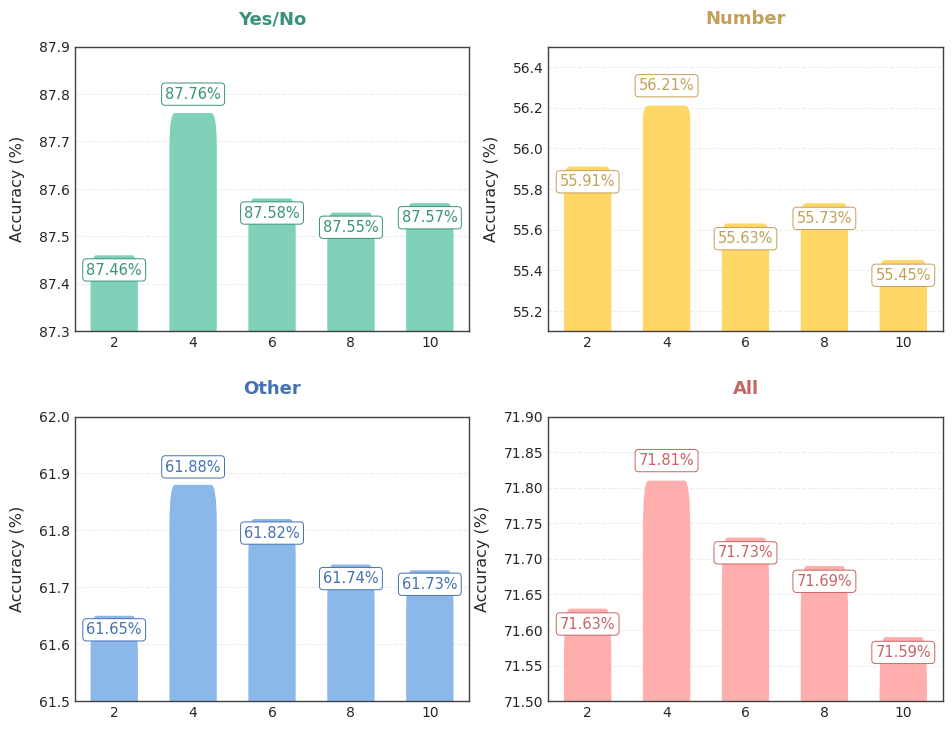

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import FancyBboxPatch

# =============== 学术级配置优化 ===============
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11.5,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#404040',
    'grid.color': '#dcdcdc',
    'text.color': '#2c2c2c',
    'axes.labelcolor': '#2c2c2c',
    'savefig.dpi': 1200,
    'savefig.format': 'eps',
    'figure.autolayout': True
})

# =============== 清新配色系统（已替换） ===============
TASK_CONFIG = {
    'Yes/No': {'color': '#7FD1B9', 'annotate': '#3A927A'},
    'Number': {'color': '#FFD766', 'annotate': '#C4A056'},
    'Other': {'color': '#8BB8E8', 'annotate': '#4372B3'},
    'All': {'color': '#FFAEAE', 'annotate': '#C86464'}
}

# =============== 圆角条形图函数 ===============
def round_bar(ax, x, height, width, color, radius=0.1):
    for xi, hi in zip(x, height):
        bbox = FancyBboxPatch(
            (xi - width/2, 0), width, hi,
            boxstyle=f"round,pad=0.0,rounding_size={radius}",
            ec='none', fc=color, zorder=2)
        ax.add_patch(bbox)

# =============== 精准标注函数 ===============
def optimized_annotation(ax, x, height, task):
    max_h = max(height)
    min_h = min(height)
    data_range = max_h - min_h if max_h != min_h else 1

    for xi, hi in zip(x, height):
        offset = data_range * 0.05 if hi != max_h else data_range * 0.08
        va = 'bottom' if hi == max_h else 'top'
        ax.text(xi,
                hi + (offset if va == 'bottom' else -offset),
                f'{hi:.2f}%',
                ha='center', va=va,
                fontsize=10.5,
                color=TASK_CONFIG[task]['annotate'],
                fontweight='medium',
                bbox=dict(boxstyle="round,pad=0.25",
                          fc='white',
                          ec=TASK_CONFIG[task]['annotate'],
                          lw=0.7))

# =============== 增强可视化主函数 ===============
def generate_advanced_plot(data):
    df = data.melt(id_vars='Iterations', var_name='Task', value_name='Accuracy')
    fig, axs = plt.subplots(2, 2, figsize=(11.2, 8.5), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})

    for idx, task in enumerate(TASK_CONFIG):
        ax = axs[idx // 2, idx % 2]
        task_data = df[df['Task'] == task].sort_values('Iterations')
        x = np.arange(len(task_data))
        accuracy = task_data['Accuracy'].values
        iter_labels = task_data['Iterations'].values

        # 添加圆角条形图
        round_bar(ax, x, accuracy, width=0.6, color=TASK_CONFIG[task]['color'], radius=0.07)

        # 标注优化
        optimized_annotation(ax, x, accuracy, task)

        # 坐标轴优化
        ax.set_xlim(-0.5, len(x) - 0.5)

        # =============== 差异化Y轴范围设置 ===============
        if task == 'Other':
            ax.set_ylim(61.5, 62.0)  # 放大差异区间
        elif task == 'All':
            ax.set_ylim(71.5, 71.9)  # 控制 All 图表纵轴
        elif task == 'Yes/No':
            ax.set_ylim(87.3, 87.9)  # 增加 Yes/No 的对比度
        elif task == 'Number':
            ax.set_ylim(55.10, 56.5)  # 增加 Yes/No 的对比度
        else:
            y_min = min(accuracy) - 0.4
            y_max = max(accuracy) + 0.6
            ax.set_ylim(y_min, y_max)
        # =================================================

        ax.set_xticks(x)
        ax.set_xticklabels(iter_labels)
        #ax.set_xlabel("Routing Iterations", labelpad=10)
        ax.set_ylabel("Accuracy (%)", labelpad=10)

        # 柔和网格
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
        ax.xaxis.grid(False)

        # 标题
        ax.text(0.5, 1.08, task, transform=ax.transAxes,
                ha='center', fontsize=13,
                color=TASK_CONFIG[task]['annotate'],
                fontweight='bold')


    return fig

# =============== 数据输入 ===============
iteration_data = pd.DataFrame({
    'Iterations': [2, 4, 6, 8, 10],
    'Yes/No': [87.46, 87.76, 87.58, 87.55, 87.57],
    'Number': [55.91, 56.21, 55.63, 55.73, 55.45],
    'Other': [61.65, 61.88, 61.82, 61.74, 61.73],
    'All': [71.63, 71.81, 71.73, 71.69, 71.59]
})

# =============== 执行流程 ===============
performance_fig = generate_advanced_plot(iteration_data)
performance_fig.savefig('./fusion1/test/test1.eps', bbox_inches='tight')
plt.show()
